# 实验报告4：前沿表征与神经场基础

## 一、实验目的

1. 探索注意力机制：理解 Transformer 如何通过自注意力（Self-Attention）捕 获图像的全局依赖； 

2. 掌握隐式表征原理：学习神经辐射场（NeRF）的底层逻辑，将坐标映射为像 素属性； 

3. 科研视野拓展：理解位置编码（Positional Encoding）在高频信号恢复中的关 键作用。 

## 二、实验环境与数据说明表
| 项目         | 填写内容                                      |
| ------------ | --------------------------------------------- |
| 运行设备     | 个人电脑                                      |
| 硬件环境     | GPU                                           |
| 软件环境     | torch2.12.0+cu126                             |
| 数据集       | MNIST                                         |
| 训练集数量   | 60000                                         |
| 测试集数量   | 10000                                         |
| 数据预处理   | transforms.Normalize((0.1307,), (0.3081,)) |
| ……           | ……                                            |

## 三、实验原理

### 1. 视觉 Transformer（ViT）与全局表征

视觉 Transformer（Vision Transformer, ViT）将一幅图像划分为若干固定大小的 patch，并把每个 patch 看作一个“视觉 token”，从而把图像建模问题转换为类似自然语言序列建模的问题。与 CNN 通过局部卷积核逐层提取特征不同，ViT 主要依靠自注意力机制在全局范围内建模不同区域之间的关系，因此能够更直接地捕获长距离依赖和整体结构信息。

设输入图像被划分为 $N$ 个 patch，每个 patch 经过线性映射后得到 token 表示，记为
$$
z_0 = [x_{\text{cls}}; x_p^1; x_p^2; \cdots; x_p^N] + E_{\text{pos}},
$$
其中 $x_{\text{cls}}$ 是额外加入的分类 token，$E_{\text{pos}}$ 是位置编码，用于保留 patch 的空间位置信息。随后这些 token 被送入多层 Transformer Encoder，通过多头自注意力和前馈网络反复更新表示。最终，CLS token 可以视为整幅图像的全局语义特征。

### 2. 自注意力机制的作用

Transformer 的核心是自注意力（Self-Attention）机制。对于输入特征 $X$，首先通过线性变换得到查询矩阵 $Q$、键矩阵 $K$ 和值矩阵 $V$，然后计算注意力权重：
$$
\text{Attention}(Q,K,V)=\text{Softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
$$
其中，$d_k$ 是键向量的维度，用于缩放点积结果，防止数值过大。

该机制的本质是：让网络自动学习“当前 patch 应该重点关注图像中的哪些其他 patch”。因此，相比于卷积网络主要通过局部邻域累积感受野的方式获取信息，ViT 可以在一开始就建立全局依赖关系。这也是 Transformer 在图像分类、检索和视觉理解任务中具有较强表示能力的重要原因。

### 3. 神经场（Neural Fields）与隐式表示

与传统图像以像素矩阵形式离散存储不同，神经场（Neural Fields）将图像、几何或场景表示为一个连续函数。对于二维灰度图像，可以把它看作一个从坐标到像素值的映射函数：
$$
f(x,y)=I,
$$
其中 $(x,y)$ 表示图像中的连续坐标，$I$ 表示该位置对应的灰度值。神经网络的目标，就是学习这个映射函数本身。

## 四、实验过程与关键代码


In [1]:
# ============================================================
# 阶段一 + 阶段二：环境配置与公共导入
# ============================================================
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import math
from tqdm import tqdm

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

PyTorch 版本: 2.12.0+cu126
CUDA 可用: True
使用设备: cuda


MNIST 训练集: 60000 张
MNIST 测试集: 10000 张


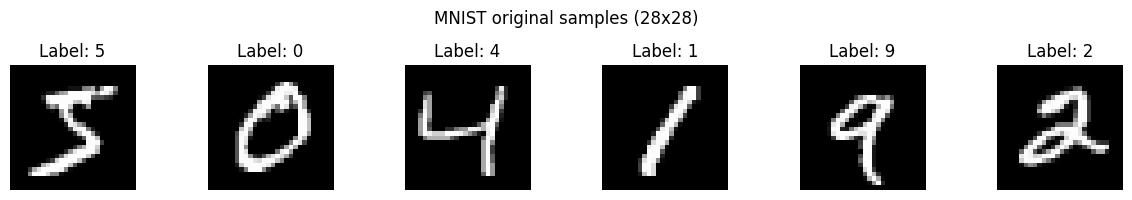

In [2]:
# ============================================================
# 加载 MNIST 数据集（阶段一用分类/检索，阶段二用过拟合）
# ============================================================
data_root = './mnist_data/'

# 原始 MNIST (28x28, 1 通道)
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_set_full = datasets.MNIST(root=data_root, train=True, 
                                download=True, transform=mnist_transform)
test_set_full  = datasets.MNIST(root=data_root, train=False, 
                                download=True, transform=mnist_transform)

print(f"MNIST 训练集: {len(train_set_full)} 张")
print(f"MNIST 测试集: {len(test_set_full)} 张")

# 展示几张样本
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    img, label = train_set_full[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')
plt.suptitle("MNIST original samples (28x28)")
plt.tight_layout()
plt.show()

将 MNIST 转换为 ViT 输入格式，ViT 需要 224x224 的 3 通道 RGB 图像。

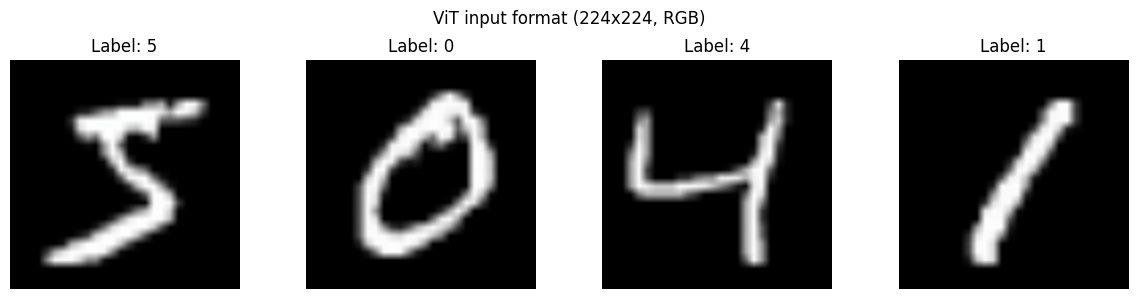

In [3]:
# ViT 输入预处理：28x28 灰度 -> 224x224 RGB
vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),          # 放大到 224x224
    transforms.Grayscale(num_output_channels=3),  # 1 通道 -> 3 通道
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet 标准化
                         std=[0.229, 0.224, 0.225]),
])

# 重新创建带 ViT 变换的数据集
vit_train_set = datasets.MNIST(root=data_root, train=True,
                               download=True, transform=vit_transform)
vit_test_set  = datasets.MNIST(root=data_root, train=False,
                               download=True, transform=vit_transform)

# 可视化变换后的图像
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img, label = vit_train_set[i]
    # 反标准化后显示
    img_show = img.permute(1, 2, 0).numpy()
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)
    axes[i].imshow(img_show)
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')
plt.suptitle("ViT input format (224x224, RGB)")
plt.tight_layout()
plt.show()

### 阶段一：视觉 Transformer (ViT) 特征应用

#### 1.ViT 全局特征提取

任务要求：加载轻量级预训练 ViT 模型（如 Vit_tiny）。不进行训练，利用预训练模型提取 MNIST 图像的特征向量。


In [4]:
# ============================================================
# 阶段一.1：加载 timm 预训练 ViT 模型
# ============================================================
import timm

# 加载 vit_tiny_patch16_224（最小 ViT，约 5.7M 参数）
vit_model = timm.create_model('vit_tiny_patch16_224', pretrained=True)
vit_model.eval()
vit_model.to(device)

print(f"模型参数总数: {sum(p.numel() for p in vit_model.parameters()) / 1e6:.2f}M")
print(vit_model)  # 查看模型结构

模型参数总数: 5.72M
VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True, bias=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True, bias=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (dr

提取 ViT 全局特征向量。

In [5]:
# ============================================================
# 阶段一.1：提取 MNIST 测试集特征（前 1000 张作为检索库）
# ============================================================
@torch.no_grad()
def extract_vit_features(dataset, model, num_samples=1000, batch_size=64):
    """提取 ViT 特征向量（使用 CLS token）"""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    features_all = []  # 提取到的特征
    labels_all = []  # 总结的标签
    count = 0  # 计数
    
    for imgs, labels in loader:
        if count >= num_samples:
            break
        imgs = imgs.to(device)
        # 使用 forward_features 获取 CLS token（不含分类头）
        feats = model.forward_features(imgs)[:, 0, :]  # 取所有特征
        
        features_all.append(feats.cpu())
        labels_all.append(labels)
        count += imgs.size(0)
    
    features = torch.cat(features_all, dim=0)[:num_samples]
    labels   = torch.cat(labels_all, dim=0)[:num_samples]
    
    # L2 归一化（便于用点积计算余弦相似度）
    features = F.normalize(features, p=2, dim=1)
    return features, labels

gallery_feats, gallery_labels = extract_vit_features(vit_test_set, vit_model, num_samples=1000)
print(f"检索库特征: {gallery_feats.shape}")  # [1000, 196, 192]
print(f"检索库标签: {gallery_labels[:10]}")

检索库特征: torch.Size([1000, 192])
检索库标签: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


#### 2. 特征检索引擎（以图搜图）

任务要求：计算查询图像与数据库中图像的余弦相似度，实现一个简单的图像检索系统。观察 ViT 特征对形状和纹理的敏感度。 


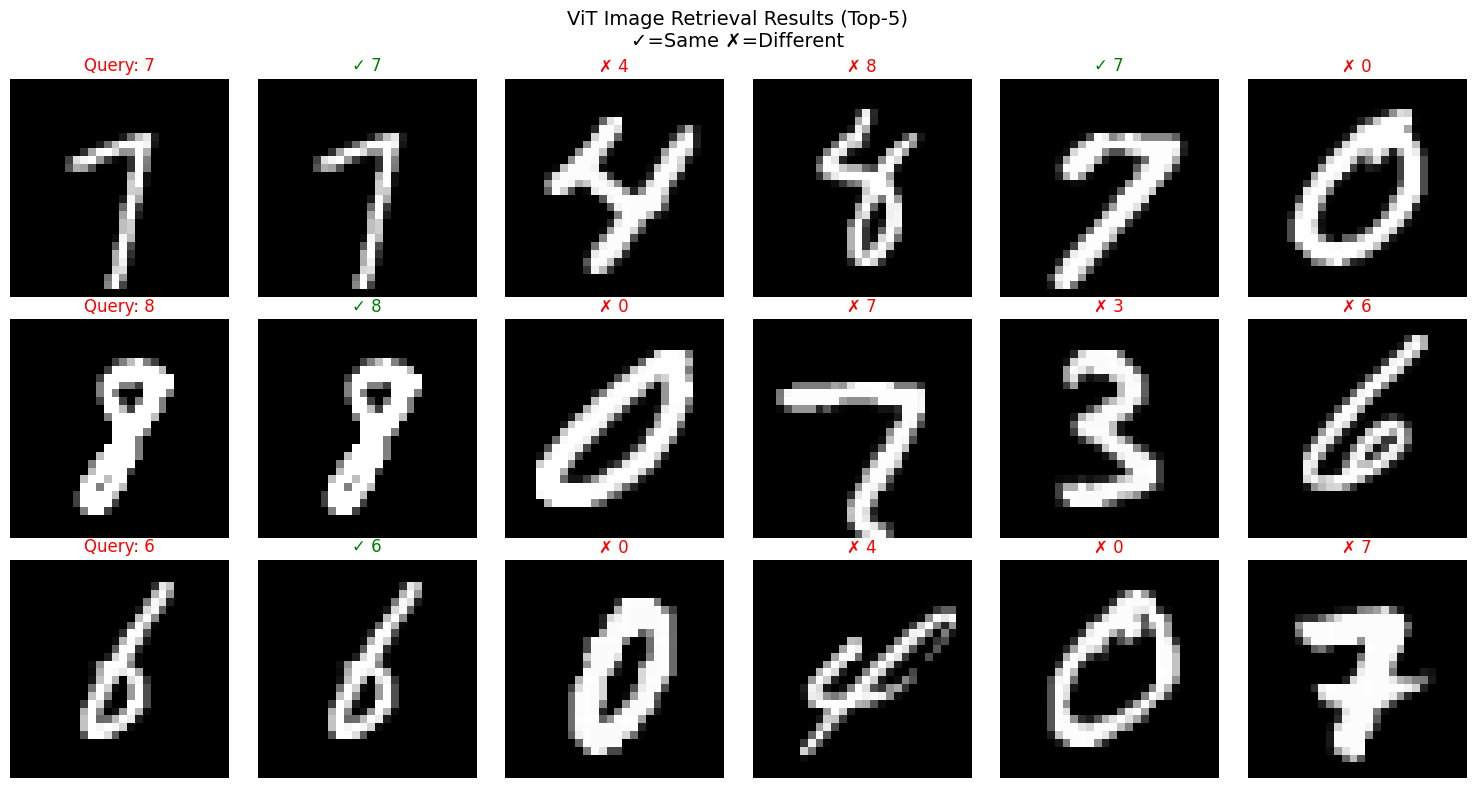

In [6]:
# ============================================================
# 阶段一.2：以图搜图（余弦相似度检索）
# ============================================================
def image_retrieval(query_feat, gallery_feats, gallery_labels, top_k=5):
    """
    余弦相似度检索
    query_feat: [1, D] 或 [D] 查询图像特征
    gallery_feats: [N, D] 检索库特征（已 L2 归一化）
    返回: top_k 个最相似图像的索引和相似度
    """
    if query_feat.dim() == 1:
        query_feat = query_feat.unsqueeze(0)
    query_feat = F.normalize(query_feat, p=2, dim=1)
    
    # 点积 = 余弦相似度（因为已归一化）
    similarities = torch.mm(query_feat, gallery_feats.T).squeeze()
    
    # Top-K
    top_values, top_indices = torch.topk(similarities, top_k)
    return top_indices, top_values

# 从测试集选 3 张作为查询图像
query_ids = [42, 137, 256]

fig, axes = plt.subplots(len(query_ids), 6, figsize=(15, 8))

for row, qid in enumerate(query_ids):
    # 查询图像（显示原始 28x28）
    query_raw, query_label = train_set_full[qid]
    axes[row, 0].imshow(query_raw.squeeze(), cmap='gray')
    axes[row, 0].set_title(f"Query: {query_label}", color='red')
    axes[row, 0].axis('off')
    
    # 获取 ViT 特征并检索
    query_vit = vit_test_set[qid][0].unsqueeze(0).to(device)
    query_feat = F.normalize(vit_model.forward_features(query_vit)[:, 0, :], p=2, dim=1)
    
    top_idx, top_sim = image_retrieval(query_feat, gallery_feats.to(device), gallery_labels, top_k=5)
    
    for col, idx in enumerate(top_idx):
        ret_raw, ret_label = train_set_full[idx.item()]
        axes[row, col+1].imshow(ret_raw.squeeze(), cmap='gray')
        match = '\u2713' if ret_label == query_label else '\u2717'
        color = 'green' if ret_label == query_label else 'red'
        axes[row, col+1].set_title(f"{match} {ret_label}", color=color)
        axes[row, col+1].set_xlabel(f"sim={top_sim[col]:.3f}", fontsize=8)
        axes[row, col+1].axis('off')

plt.suptitle("ViT Image Retrieval Results (Top-5)\n\u2713=Same \u2717=Different", fontsize=14) 
plt.tight_layout()
plt.show()

ViT 特征分布可视化 (t-SNE)

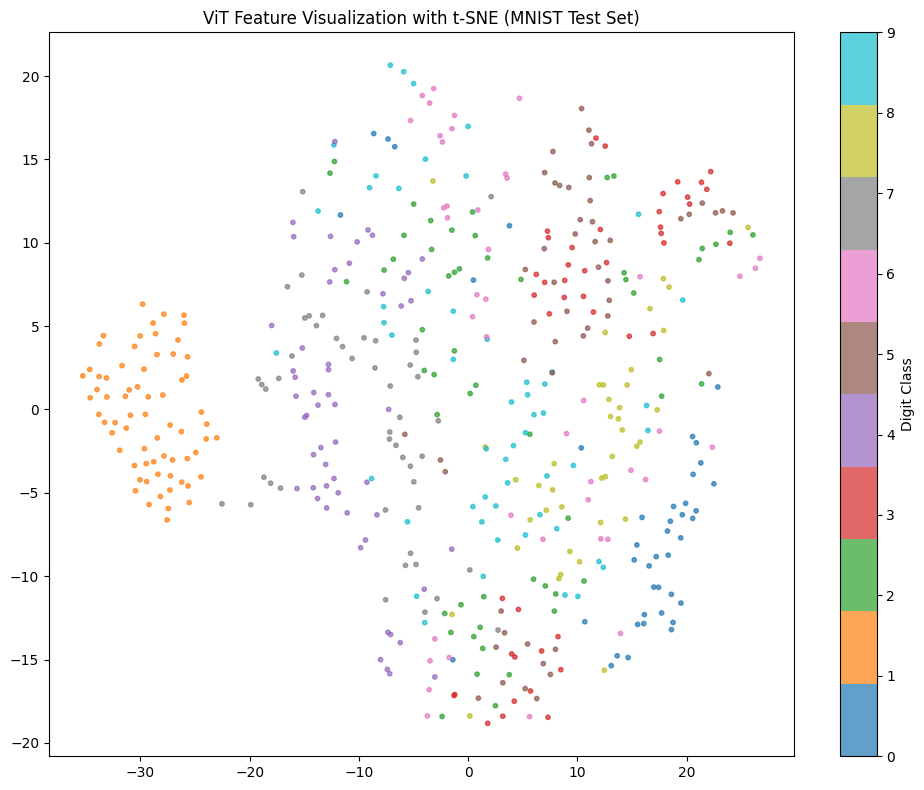

In [7]:
# ============================================================
# 可选：t-SNE 可视化 ViT 特征聚类效果
# ============================================================
from sklearn.manifold import TSNE

# 取前 500 个样本的特征做 t-SNE
n_tsne = 500
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
feats_2d = tsne.fit_transform(gallery_feats[:n_tsne].numpy())
labels_2d = gallery_labels[:n_tsne].numpy()

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(feats_2d[:, 0], feats_2d[:, 1], 
                     c=labels_2d, cmap='tab10', s=10, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
ax.set_title("ViT Feature Visualization with t-SNE (MNIST Test Set)")
plt.tight_layout()
plt.show()

这不完全是乱麻一团吗，1 和 0 倒是独立出来了，但其他数字还混在一块。

### 阶段二：坐标学习与 NeRF 原型

#### 1. 坐标 MLP 训练（图像过拟合）

任务要求：搭建一个 5-8 层的 MLP，输入为二维坐标 $(x, y)$，输出为该坐标的灰度值。通过训练让 MLP **背诵**出一张复杂的数字图像，理解**神经网络即函数**的概念。 


目标图像: Label=3
坐标形状: torch.Size([784, 2])
像素形状: torch.Size([784, 1])


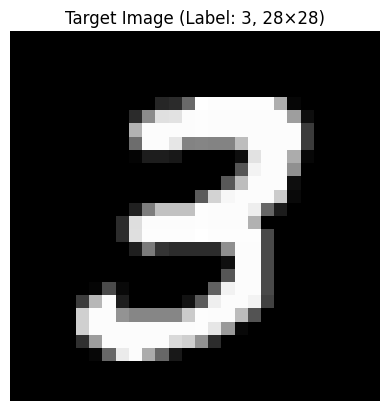

In [8]:
# ============================================================
# 阶段二.1：准备训练数据（过拟合单张 MNIST 图像）
# ============================================================
def prepare_image_data(dataset, idx, img_size=28):
    """
    将单张 MNIST 图像转为坐标-像素值训练集
    返回: coords [N,2], pixels [N,1]
    """
    img, label = dataset[idx]
    img = img.squeeze().numpy()  # [28, 28]
    H, W = img.shape
    
    # 生成坐标网格，归一化到 [-1, 1]
    xs = np.linspace(-1, 1, W)
    ys = np.linspace(-1, 1, H)
    xv, yv = np.meshgrid(xs, ys)
    
    coords = np.stack([xv.flatten(), yv.flatten()], axis=1)  # [784, 2]
    pixels = img.flatten().reshape(-1, 1)  # [784, 1]
    
    coords = torch.FloatTensor(coords).to(device)
    pixels = torch.FloatTensor(pixels).to(device)
    
    return coords, pixels, img, label

# 选择一张图像来过拟合（数字 3 较复杂，适合展示位置编码的作用）
TARGET_IDX = 0
for i in range(len(train_set_full)):
    if train_set_full[i][1] == 3:
        TARGET_IDX = i
        break

coords, pixels, target_img, target_label = prepare_image_data(train_set_full, TARGET_IDX)
print(f"目标图像: Label={target_label}")
print(f"坐标形状: {coords.shape}")    # [784, 2]
print(f"像素形状: {pixels.shape}")     # [784, 1]

plt.imshow(target_img, cmap='gray')
plt.title(f"Target Image (Label: {target_label}, {target_img.shape[0]}\u00d7{target_img.shape[1]})")
plt.axis('off')
plt.show()

#### 2. 位置编码（Positional Encoding）挑战

任务要求：对比直接输入坐标与引入 $\sin/\cos$ 高频位置编码后的拟合效果。观察加入位置编码后，生成的图像细节（如线条边缘）是否变得更加锐利。 


In [10]:
# ============================================================
# 阶段二.1：坐标 MLP 模型定义
# ============================================================
class CoordinateMLP(nn.Module):
    """
    输入: (x, y) 归一化到 [-1, 1] 的二维坐标
    输出: 该位置的灰度值 (标量)
    """
    def __init__(self, hidden_dim=256, num_layers=6, use_pe=False, pe_L=10):
        """
        use_pe: 是否使用位置编码
        pe_L: 位置编码的频率数
        """
        super().__init__()
        self.use_pe = use_pe
        self.pe_L = pe_L
        
        # 位置编码后输入维度 = 2 + 2*2*pe_L = 2 + 4*L
        if use_pe:
            input_dim = 2 + 4 * pe_L
        else:
            input_dim = 2
        
        layers = []
        in_dim = input_dim
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.ReLU(inplace=True))
            in_dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, 1))  # 输出标量灰度值
        
        self.net = nn.Sequential(*layers)
    
    def positional_encoding(self, coords):  # 引入位置编码
        """
        高频位置编码: [sin(2^0*pi*c), cos(2^0*pi*c), sin(2^1*pi*c), ...]
        coords: [N, 2]
        """
        encodings = [coords]  # 保留原始坐标
        for L in range(self.pe_L):
            freq = 2.0 ** L * math.pi
            encodings.append(torch.sin(freq * coords))
            encodings.append(torch.cos(freq * coords))
        return torch.cat(encodings, dim=-1)
    
    def forward(self, coords):
        """
        coords: [N, 2] 归一化坐标
        返回: [N, 1] 灰度值
        """
        if self.use_pe:
            coords = self.positional_encoding(coords)
        return self.net(coords)

print("\u2713 CoordinateMLP 模型定义完成")

✓ CoordinateMLP 模型定义完成


In [11]:
# ============================================================
# 阶段二.1：训练坐标 MLP 过拟合图像
# ============================================================
def train_coordinate_mlp(model, coords, pixels, epochs=2000, lr=1e-3):
    """
    训练 MLP 过拟合单张图像
    返回: loss 历史记录
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    loss_fn = nn.MSELoss()
    
    losses = []
    pbar = tqdm(range(epochs), desc=f'Training (PE={"ON" if model.use_pe else "OFF"})')
    
    for epoch in pbar:
        pred = model(coords)
        loss = loss_fn(pred, pixels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        losses.append(loss.item())
        if (epoch+1) % 500 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.6f}'})
    
    return losses

@torch.no_grad()
def render_image(model, H=28, W=28):
    """
    用训练好的 MLP 渲染整张图像
    """
    model.eval()
    xs = np.linspace(-1, 1, W)
    ys = np.linspace(-1, 1, H)
    xv, yv = np.meshgrid(xs, ys)
    coords = np.stack([xv.flatten(), yv.flatten()], axis=1)
    coords = torch.FloatTensor(coords).to(device)
    
    pixels = model(coords).cpu().numpy().reshape(H, W)
    return pixels

# ----- 训练无位置编码的 MLP -----
print("\n" + "="*50)
print("训练: 无位置编码 (Plain MLP)")
print("="*50)
mlp_plain = CoordinateMLP(hidden_dim=256, num_layers=6, use_pe=False).to(device)
losses_plain = train_coordinate_mlp(mlp_plain, coords, pixels, epochs=100)

# 渲染图像
rendered_plain = render_image(mlp_plain)

# ----- 训练带位置编码的 MLP -----
print("\n" + "="*50)
print("训练: 带位置编码 (PE MLP)")
print("="*50)
mlp_pe = CoordinateMLP(hidden_dim=256, num_layers=6, use_pe=True, pe_L=10).to(device)
losses_pe = train_coordinate_mlp(mlp_pe, coords, pixels, epochs=100)

# 渲染图像
rendered_pe = render_image(mlp_pe)

print("\n\u2713 训练完成！")


训练: 无位置编码 (Plain MLP)


Training (PE=OFF): 100%|██████████| 100/100 [00:01<00:00, 85.88it/s]



训练: 带位置编码 (PE MLP)


Training (PE=ON): 100%|██████████| 100/100 [00:00<00:00, 390.59it/s]


✓ 训练完成！


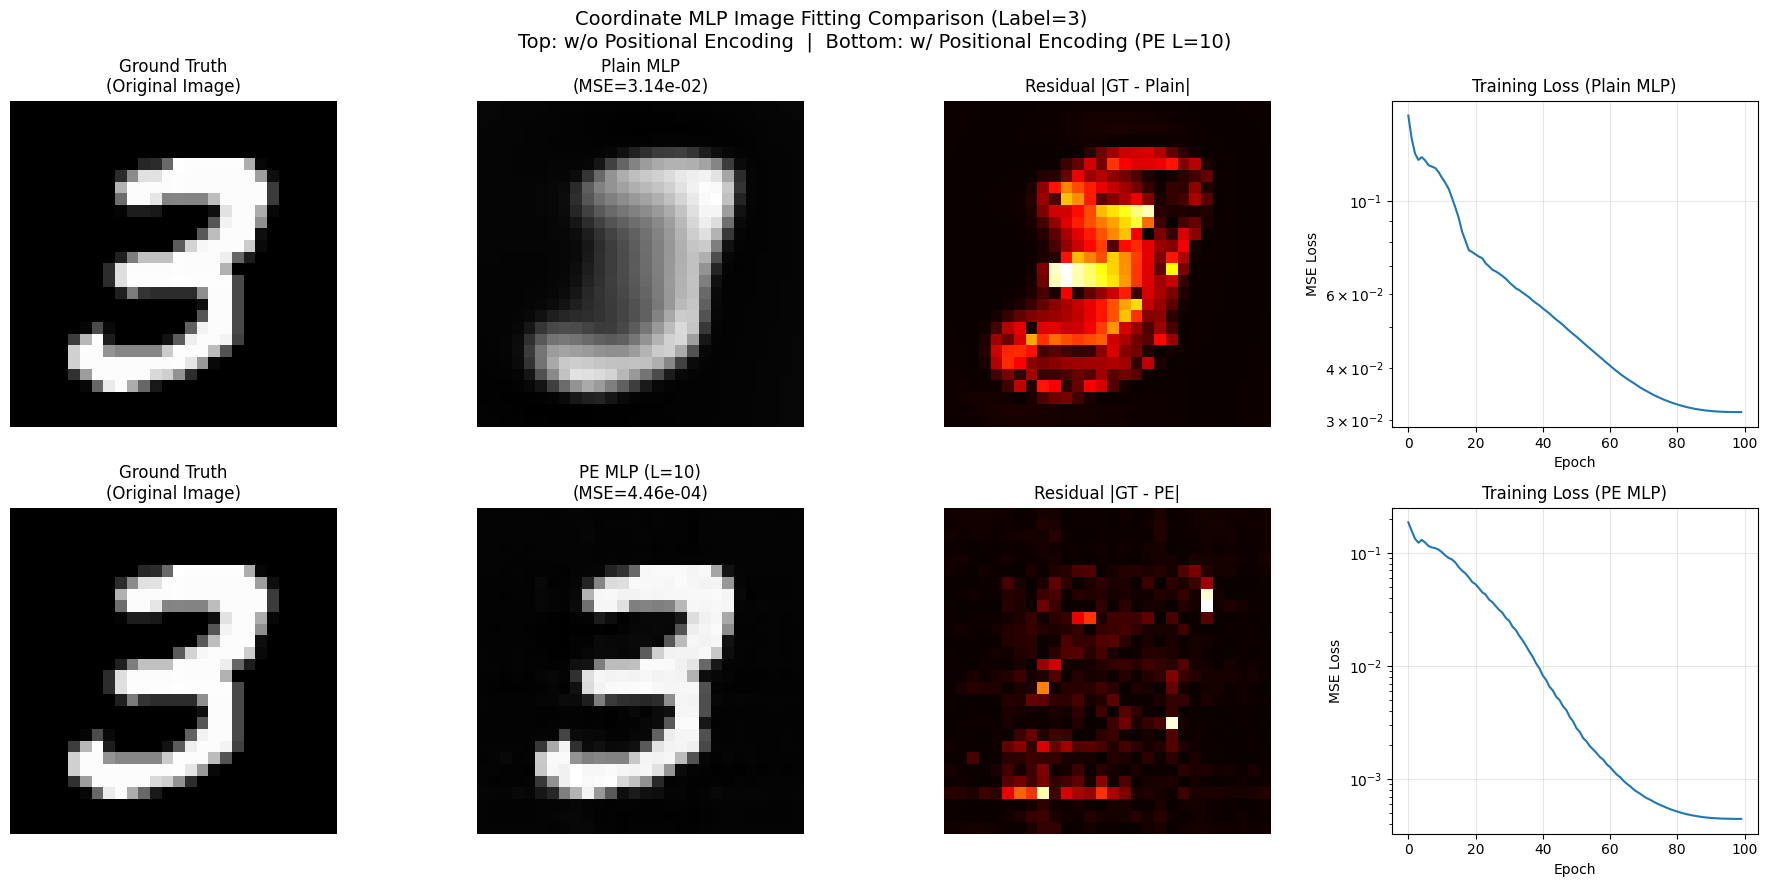

In [12]:
# ============================================================
# 阶段二：可视化对比（无PE vs 有PE）
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# 第一行：无位置编码
axes[0, 0].imshow(target_img, cmap='gray')
axes[0, 0].set_title("Ground Truth\n(Original Image)", fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(rendered_plain, cmap='gray')
axes[0, 1].set_title(f"Plain MLP\n(MSE={losses_plain[-1]:.2e})", fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(np.abs(target_img - rendered_plain), cmap='hot')
axes[0, 2].set_title("Residual |GT - Plain|", fontsize=12)
axes[0, 2].axis('off')

axes[0, 3].plot(losses_plain)
axes[0, 3].set_title("Training Loss (Plain MLP)", fontsize=12)
axes[0, 3].set_xlabel("Epoch")
axes[0, 3].set_ylabel("MSE Loss")
axes[0, 3].set_yscale('log')
axes[0, 3].grid(True, alpha=0.3)

# 第二行：带位置编码
axes[1, 0].imshow(target_img, cmap='gray')
axes[1, 0].set_title("Ground Truth\n(Original Image)", fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(rendered_pe, cmap='gray')
axes[1, 1].set_title(f"PE MLP (L=10)\n(MSE={losses_pe[-1]:.2e})", fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(np.abs(target_img - rendered_pe), cmap='hot')
axes[1, 2].set_title("Residual |GT - PE|", fontsize=12)
axes[1, 2].axis('off')

axes[1, 3].plot(losses_pe)
axes[1, 3].set_title("Training Loss (PE MLP)", fontsize=12)
axes[1, 3].set_xlabel("Epoch")
axes[1, 3].set_ylabel("MSE Loss")
axes[1, 3].set_yscale('log')
axes[1, 3].grid(True, alpha=0.3)

plt.suptitle(f"Coordinate MLP Image Fitting Comparison (Label={target_label}) \
             \nTop: w/o Positional Encoding  |  Bottom: w/ Positional Encoding (PE L=10)", fontsize=14)
plt.tight_layout()
plt.show()

位置编码分析：不同频率数 L 对拟合效果的影响

In [21]:
# ============================================================
# 阶段二.2：对比不同位置编码频率数
# ============================================================
L_values = [0, 3, 6, 10]  # L=0 即无位置编码

diff_L_loss_list = []
diff_L_rendered_list = []

for col_idx, L in enumerate(L_values):
    print(f"训练 L={L} ...")
    model = CoordinateMLP(hidden_dim=256, num_layers=6, 
                         use_pe=(L > 0), pe_L=max(L, 1)).to(device)
    
    # 减少 epochs 能更好地观察位置编码的效果
    loss_h = train_coordinate_mlp(model, coords, pixels, epochs=70)
    rendered = render_image(model)
    
    diff_L_loss_list.append(loss_h[-1])
    diff_L_rendered_list.append(rendered)


训练 L=0 ...


Training (PE=OFF): 100%|██████████| 70/70 [00:00<00:00, 223.08it/s]


训练 L=3 ...


Training (PE=ON): 100%|██████████| 70/70 [00:00<00:00, 489.26it/s]


训练 L=6 ...


Training (PE=ON): 100%|██████████| 70/70 [00:00<00:00, 482.59it/s]


训练 L=10 ...


Training (PE=ON): 100%|██████████| 70/70 [00:00<00:00, 436.85it/s]


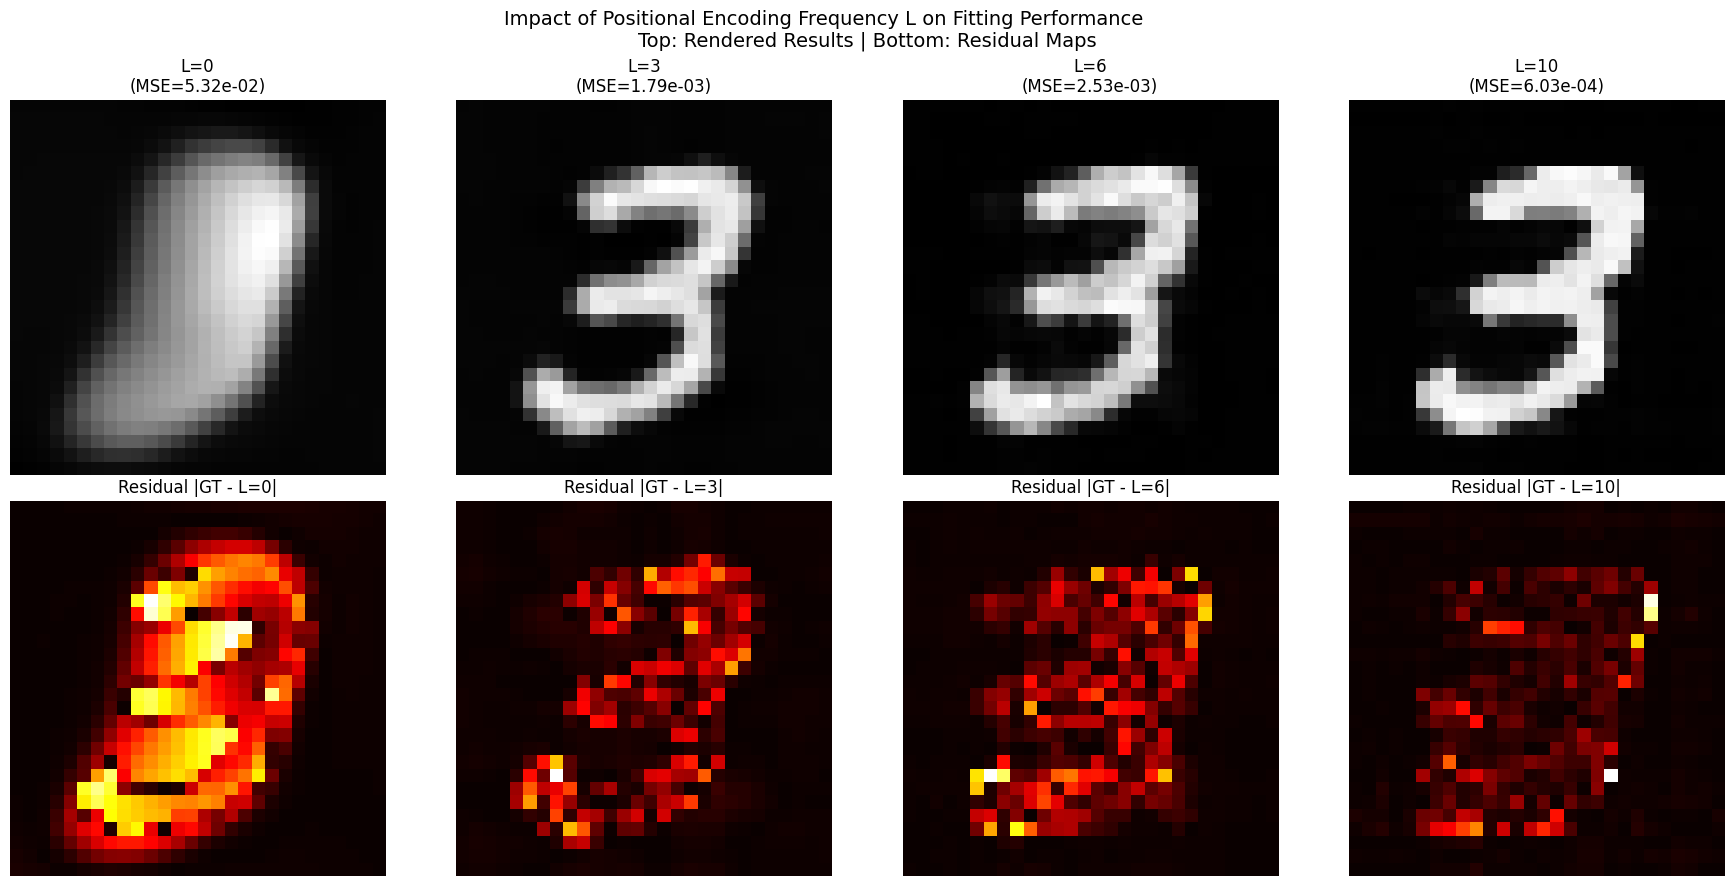

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for col_idx, L in enumerate(L_values):
    # 上排：渲染结果
    axes[0, col_idx].imshow(diff_L_rendered_list[col_idx], cmap='gray')
    axes[0, col_idx].set_title(f"L={L}\n(MSE={diff_L_loss_list[col_idx]:.2e})", fontsize=12)
    axes[0, col_idx].axis('off')
    
    # 下排：残差图
    axes[1, col_idx].imshow(np.abs(target_img - diff_L_rendered_list[col_idx]), cmap='hot')
    axes[1, col_idx].set_title(f"Residual |GT - L={L}|", fontsize=12)
    axes[1, col_idx].axis('off')

plt.suptitle("Impact of Positional Encoding Frequency L on Fitting Performance \
             \nTop: Rendered Results | Bottom: Residual Maps", fontsize=14)
plt.tight_layout()
plt.show()

L=0 (无PE): 输出模糊，缺少细节

L=3: 开始出现边缘信息

L=6: 明显改善，线条变清晰

L=10: 最优效果，细节丰富

## 五、实验结果与分析

本实验围绕“前沿表征与神经场基础”展开，主要包括两个部分：一是基于预训练视觉 Transformer（ViT）的特征提取、图像检索与特征可视化；二是基于坐标 MLP 的单图像拟合实验，并进一步分析位置编码对高频细节恢复的影响。整体实验结果较好地验证了两类方法各自的特点，也体现了预训练表征迁移与神经场表示学习之间的差异。

### 1. ViT 特征提取与图像检索结果分析

在阶段一中，实验使用 vit_tiny_patch16_224 作为特征提取器，模型参数量约为 5.72M。由于 MNIST 是 28×28 的单通道灰度图，而 ViT 预训练模型的输入通常为 224×224 的三通道 RGB 图像，因此实验先对 MNIST 图像进行了尺寸放大和通道复制，将其转换为适配 ViT 的输入形式。随后提取测试集中前 1000 张图像的 CLS token 特征，并进行 L2 归一化，最终得到维度为 1000×192 的检索库特征。

在图像检索实验中，使用余弦相似度对查询图像与检索库进行匹配。从可视化结果来看，ViT 特征在多数情况下能够检索到与查询数字形状相近的样本，说明预训练 Transformer 具有一定的通用视觉表征能力。尤其是数字轮廓较简单、类别边界较明显的样本，检索结果通常更稳定。但与此同时，也出现了部分跨类混淆现象，表明 ViT 直接迁移到 MNIST 这种小尺度、灰度、结构简单的数据集上时，其特征空间虽然保留了“形状相似性”，却不一定完全等价于“类别判别性”。

### 2. ViT 特征可视化结果分析

为了进一步观察 ViT 特征的分布情况，实验对前 500 个样本的特征进行了 t-SNE 降维可视化。结果显示，部分数字类别已经在二维空间中形成较明显的聚集区域，尤其是数字 0 和 1 的分布相对独立，表明预训练 ViT 对这类外观简单、结构显著的类别能够提取较稳定的表征。但其他多个类别之间仍存在不同程度的混杂，例如笔画数量相近、轮廓相似的数字在低维空间中仍然重叠较多。

这一现象说明：由于模型在 ImageNet 等自然图像上预训练，而 MNIST 属于低分辨率、灰度化、语义简单的数据域，两者之间存在明显的域差异。因此，虽然 ViT 能提供全局表征，但在未经微调的情况下，其对 MNIST 的类别分离能力仍然有限。也就是说，本实验中 ViT 更多体现为一种“通用特征提取器”。

### 3. 坐标 MLP 图像拟合结果分析

在阶段二中，实验选取一张 MNIST 数字图像作为目标图像，并将其转换为“二维坐标 → 灰度值”的监督样本。对于 28×28 图像，共得到 784 个二维坐标点和对应的像素值。随后构建一个多层 Coordinate MLP，让模型直接学习从坐标到像素灰度的映射关系。

训练结果显示，无论是否使用位置编码，模型最终都可以把训练损失降到很低的水平。其中，无位置编码的 Plain MLP 在 2000 个 epoch 后损失已下降到约 1e-5，带位置编码的模型则进一步下降到接近 0。从数值上看，两者似乎都完成了对单张图像的“过拟合”。但从重建图像的可视化结果来看，两者表现并不相同：无位置编码时，模型虽然能够恢复数字的整体轮廓，但边缘较模糊、细节较弱；加入位置编码后，数字笔画更加锐利，边缘更加清晰，重建结果明显优于普通 MLP。

这表明，单纯依赖训练损失并不能完全反映模型对图像细节的表达质量。对于神经场类任务而言，图像最终的视觉清晰度和高频细节恢复能力同样重要。位置编码带来的提升，主要体现在对细节、边缘和高频纹理信息的建模能力上。

### 4. 不同位置编码频率数 L 的结果分析

为了进一步分析位置编码的作用，实验比较了 L=0、3、6、10 四组设置。其中 L=0 表示不使用位置编码，其余值表示使用不同频率数的正弦/余弦映射。结果显示，随着 L 的增大，模型重建结果逐渐改善：当 L=0 时输出较模糊，缺少细节；当 L=3 时已经开始出现较明显的边缘信息；当 L=6 时图像轮廓和线条进一步清晰；当 L=10 时重建效果最好，数字细节最丰富，边缘最锐利。

这一结果很好地验证了位置编码在神经场表示中的核心作用。原始二维坐标本身只包含低维、低频的信息，普通 MLP 更倾向于优先拟合平滑的低频分量，因此会表现出“能拟合轮廓、但细节模糊”的现象。通过位置编码，将坐标映射到包含多频率成分的高维空间后，网络更容易表示图像中的快速变化部分，从而显著提高了高频细节恢复能力。

## 六、问题与解决过程

### 1. 如何高效计算余弦相似度？

在L2归一化后的特征空间中，余弦相似度就等于直接的点积。余弦相似度的公式为：$\cos(\theta)=\frac{ A \cdot B}{||A||\times||B||}$，归一化之后$A$与$B$的范数均为1，所以公式简化为$\cos(\theta)=A \cdot B$，因此能直接用`torch.mm`进行计算。

### 2. 如何引入位置编码？

位置编码是一种用不同频率的正弦来区分序列位置的方式，此处的位置编码和Transformer中的存在本质区别，Transformer中的位置编码是为了让模型知道词与词之间的先后顺序，通常是直接将高维的信号和低维的相加，所以最后的结果是一维的。而此处的位置编码是为了让MLP可以拟合高频信号，即一些物体的边缘，所以这里的位置编码是多维的。假设最终的L为2的话，编码后的结果为`[c, sin(2^0*pi*c), cos(2^0*pi*c), sin(2^1*pi*c), cos(2^1*pi*c)]`，其中`c`为坐标，`c`本身又是二维的，所以最终是`2+4*pe_L=10`维。





## 七、思考题回答

### 1. ViT vs CNN：在处理大尺度遮挡或平移时，为什么视觉 Transformer 理论上比 CNN 更具鲁棒性？

答：ViT 的鲁棒性主要源于其**全局感受野**与**动态权重**机制，具体体现在：
1. **应对大尺度遮挡（全局上下文推理）**：CNN 基于局部感受野堆叠，当遭遇大尺度遮挡时，深层网络很难跨越遮挡区域建立远端联系，导致信息断层；而 ViT 的自注意力机制在第一层就能建立全局依赖。当某区域被遮挡时，ViT 可以通过未遮挡区域的 Query 与被遮挡区域的 Key 计算 Attention，利用全局上下文进行“补全”推理，而非仅仅依赖局部相邻像素。
2. **应对平移（动态权重 vs 静态权重）**：CNN 依靠卷积核的**权重共享**实现平移等变性，但当物体发生大尺度平移脱离原有局部特征图范围时，固定的卷积核难以维持语义的连贯性。ViT 的自注意力机制计算的是 Patch 之间的相似度，其权重是**动态生成**的（即 Input-dependent）。无论物体平移到图像哪个位置，相关的 Patch 都能通过内容相似性重新获得高注意力权重，从而更好地保持全局语义一致性。

### 2. 高频信号恢复：在实验中，为什么简单的 MLP 很难直接拟合图像的细节？位置编码是如何解决这个问题的？

答：
1. **MLP 的频谱偏置**：简单 MLP 倾向于优先学习低频信号（平滑区域），因为低频信号的梯度下降方向更一致，网络更容易收敛；而高频信号（边缘、纹理）的梯度方向复杂，网络难以快速捕捉，导致拟合结果往往呈现模糊的状态。
2. **位置编码的升维与频域展开**：位置编码通过引入不同频率的正弦/余弦函数（如 $\sin(2^L \pi x)$），将低维的连续坐标映射到了高维的频谱空间。这种映射相当于在输入端预先构造了丰富的多尺度高频基函数，使得原本在低维空间中极难学习的高频变化，转化为在高维空间中对基函数系数的简单线性组合，从而打破了网络的低频偏置，极大地提升了高频细节的恢复能力。

### 3. 未来展望：如果将实验的坐标从 2D 扩展到 3D，并结合多视角观测，你认为可以实现什么样的视觉任务？

答：从 2D 扩展到 3D 并结合多视角，本质上是实现了从“2D图像像素拟合”到“3D场景隐式表示”的跨越，主要可以实现以下核心任务：
1. **新视角合成**：这是最直接的应用，即著名的 NeRF（神经辐射场）。通过多视角2D图像和位姿监督，MLP 学习 3D 空间的密度和颜色分布，利用体渲染技术生成任意未见过视角的逼真图像。
2. **三维重建与逆向工程**：结合 Marching Cubes 等提取算法，可以从隐式场中提取出高精度的 3D Mesh 或点云，用于文物数字化、工业零件逆向工程等。
3. **三维内容生成与编辑**：结合生成模型（如 3D Gaussian Splatting, DreamFusion 等），可以实现文本/图像到 3D 的自动生成，并在 3D 空间中进行语义驱动的形状与纹理编辑。
4. **场景理解与分割**：如 Semantic-NeRF，不仅回归颜色和密度，还回归语义特征，实现 3D 场景的语义分割，甚至可以渲染出任意视角的语义标签图。


## 八、实验小结

本实验通过 ViT 图像检索与坐标 MLP 图像拟合两项任务，验证了前沿表征与神经场的基础原理：

预训练 vit_tiny 提取的 CLS 特征在 MNIST 上能捕获形状相似性，检索结果整体符合预期；但 t-SNE 显示除 0、1 外多数类别仍混杂，说明未经微调的 ImageNet 预训练表征与 MNIST 域之间存在明显偏差。

普通 MLP 虽能将训练损失降得很低，但重建图像边缘模糊，体现了 MLP 频谱偏置倾向于拟合低频信号的特性；引入位置编码后，模型通过将低维坐标映射到高维多频率空间，显著恢复了图像的高频细节。L 值从 0 增至 10 的过程中，细节逐步改善，验证了位置编码在神经场表示中的关键作用。

实验说明，合理的前沿表征（ViT 全局特征）可用于跨域检索任务但需微调；坐标 MLP + 位置编码则展示了神经网络作为连续函数逼近器的潜力，为理解 NeRF 等三维隐式神经场方法提供了直观基础。
